# KeyPoint Classifier Training Pipeline
This notebook completely rewrites the old training pipeline for hand gesture classification using modern TensorFlow 2.16 and Keras 3 APIs.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

## 1. Setup Environment
Let's set some random seeds for reproducibility.

In [ ]:
def set_random_seeds(seed=42):
    """Sets random seeds for reproducibility across Python, NumPy, and TensorFlow."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_random_seeds(42)

# Determine the directory structure.
base_dir = os.path.abspath('')
model_dir = os.path.join(base_dir, 'model', 'keypoint_classifier')

dataset_path = os.path.join(model_dir, 'keypoint.csv')
keras_model_path = os.path.join(model_dir, 'keypoint_classifier.keras')

print(f"Dataset Path: {dataset_path}")

Dataset Path: c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\keypoint_classifier\keypoint.csv


## 2. Load Dataset
The format is `label`, followed by `63` normalized landmark values.

In [ ]:
# Load the dataset
df = pd.read_csv(dataset_path, header=None)

# Separate labels and features
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

# Calculate the max label + 1 dynamically as the number of classes
num_classes = int(np.max(y) + 1)
print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features, {num_classes} classes.")

Dataset loaded: 4791 samples, 42 features, 5 classes.


## 3. Train/Test Split
We will split the dataset into an 80/20 train/test distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (3832, 42)
Test data shape: (959, 42)


## 4. Build Neural Network Model
A sequential neural network architecture tailored for extracting features out of point-spatial arrays.

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,085 (55.02 KB)

 Trainable params: 14,085 (55.02 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Define Callbacks
We use standard Adam optimization with early stopping to prevent overfitting.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=keras_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

## 6. Train the Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,            
    batch_size=128,
    validation_split=0.2, 
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/100
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4137 - loss: 1.3700
Epoch 1: val_accuracy improved from None to 0.68188, saving model to c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\keypoint_classifier\keypoint_classifier.keras

Epoch 1: finished saving model to c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\keypoint_classifier\keypoint_classifier.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4330 - loss: 1.3337 - val_accuracy: 0.6819 - val_loss: 1.0348
Epoch 2/100
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5933 - loss: 0.9967 
Epoch 2: val_accuracy improved from 0.68188 to 0.79661, saving model to c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\keypoint_classifier\keypoint_classifier.keras

Epoch 2: finished saving model to c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\model\keypoint_classifier\keypoint_classifier.keras
24/24 ━━━━━━━━━━━━━━━━━━━━

## 7. Evaluate the Pipeline

In [ ]:
# Get last epoch training and validation stats
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

# Get test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("\n--- Training Results ---")
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print("------------------------\n")


--- Training Results ---
Training Accuracy:   0.9935
Validation Accuracy: 0.9974
Test Accuracy:       0.9948
------------------------



## 8. Generate Visualizations & Classifications

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       305
           1       1.00      0.99      0.99       315
           2       1.00      1.00      1.00       271
           3       1.00      1.00      1.00        67
           4       0.00      0.00      0.00         1

    accuracy                           0.99       959
   macro avg       0.80      0.80      0.80       959
weighted avg       0.99      0.99      0.99       959



c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\moham\OneDrive\Desktop\hand-gesture-recognition-mediapipe\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

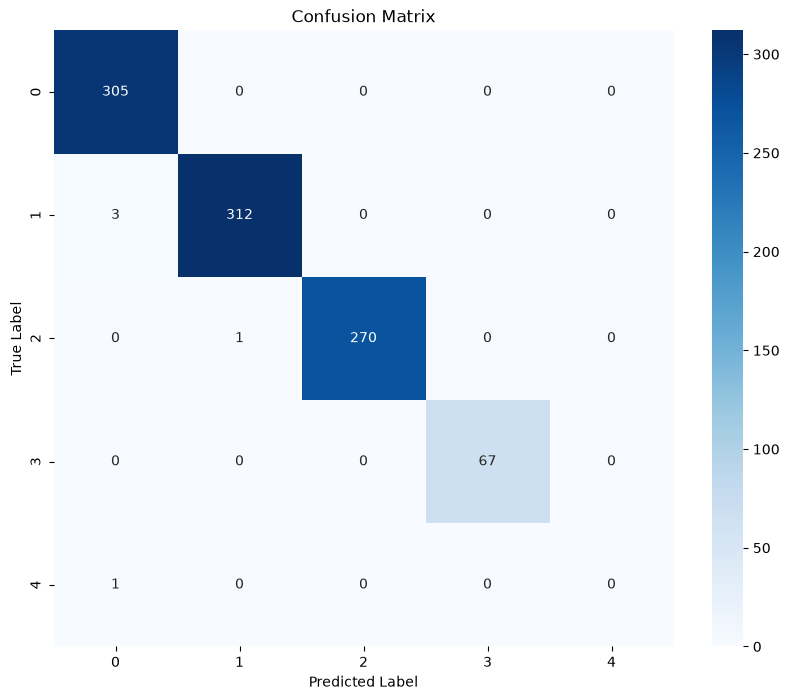

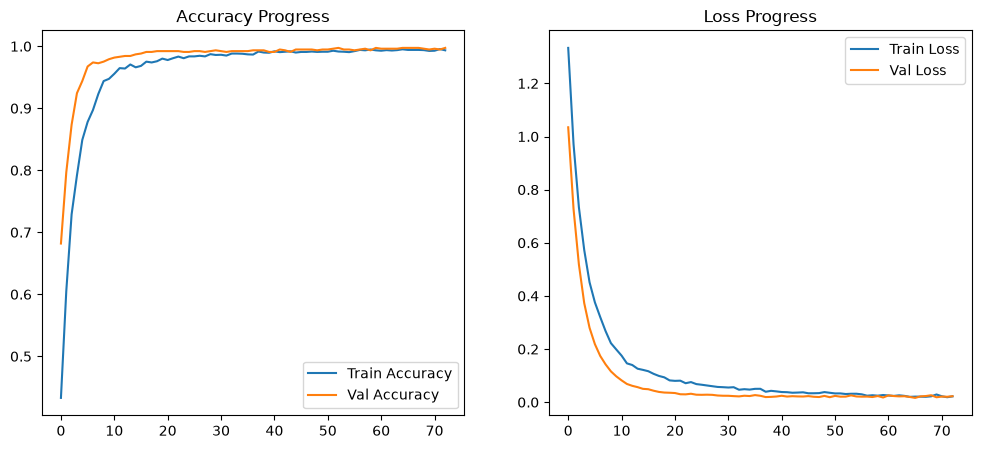

Training notebook completed successfully.


In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Accuracy Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Progress')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Progress')
plt.legend()
plt.show()

print("Training notebook completed successfully.")